# **Load Dataset and Performed EDA**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/final_labeled_fake_reviews.csv")
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,label,user_timestamp,user_review_burst
0,5,You will love it!,It’s battery powered! Love love it! Works perf...,[],B07CVHWC68,B07CVHWC68,AHX4JB6F63PSFWZQFFT25RWUHUBQ,3/2/2021 1:53,0,True,0,99999,99999.0
1,5,"Good, clean soap",Good stuff! Yes - it's weird to cover yoursel...,[],B00T6PYPII,B00T6PYPII,AG3VGU4WE6EMBVINQJXNOAXYBU6Q,3/30/2017 16:06,3,True,0,99999,99999.0
2,5,Love It !!!,I've had this for a little over a month now an...,[],B000A23CQM,B000A23CQM,AG3RTC4CY5NWUGG4342GDMGGNKYA,7/24/2008 14:33,0,False,1,99999,99999.0
3,2,Two Stars,Lashes ere too short didn’t fit my eye,[],B00KDIW98K,B00KDIW98K,AEO7IGCEYEDB4J2I7WODOWKR2EMA,11/21/2017 2:06,0,True,0,99999,99999.0
4,1,I can’t used,The magnet doesn’t work is impossible to used....,[],B09LR3G8QL,B09LR3G8QL,AEI4DI2SS5R3KZ4PJ47FR6WZI2KA,12/23/2021 22:53,0,True,0,99999,99999.0


In [4]:
df.shape
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'label',
       'user_timestamp', 'user_review_burst'],
      dtype='object')

In [5]:
df['label'].value_counts()

,count
label,
0,25281
1,24719


In [6]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
0,50.562
1,49.438


In [7]:
df[df['label'] == 1]['text'].sample(5)

,text
32204,Best purchase ever!!!
16288,Es muy rico y duradero
49617,My hair looks healthy now.
12643,You only get one bottle.
28502,Me encanto


In [8]:
df.groupby('label')['verified_purchase'].value_counts(normalize=True)

label  verified_purchase
0      True                 1.000000
1      True                 0.611716
       False                0.388284
Name: proportion, dtype: float64

In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             50000 non-null  int64  
 1   title              49990 non-null  object 
 2   text               49988 non-null  object 
 3   images             50000 non-null  object 
 4   asin               50000 non-null  object 
 5   parent_asin        50000 non-null  object 
 6   user_id            50000 non-null  object 
 7   timestamp          50000 non-null  object 
 8   helpful_vote       50000 non-null  int64  
 9   verified_purchase  50000 non-null  bool   
 10  label              50000 non-null  int64  
 11  user_timestamp     50000 non-null  int64  
 12  user_review_burst  50000 non-null  float64
dtypes: bool(1), float64(1), int64(4), object(7)
memory usage: 4.6+ MB


,0
rating,0
title,10
text,12
images,0
asin,0
parent_asin,0
user_id,0
timestamp,0
helpful_vote,0
verified_purchase,0


In [10]:
df['rating'].value_counts()
df.groupby('label')['rating'].mean()

,rating
label,
0,3.842688
1,3.903151


In [11]:
df['review_length'] = df['text'].str.len()
df.groupby('label')['review_length'].mean()

,review_length
label,
0,176.088924
1,139.538125


In [12]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

In [13]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,label,user_timestamp,user_review_burst,review_length,word_count
0,5,You will love it!,It’s battery powered! Love love it! Works perf...,[],B07CVHWC68,B07CVHWC68,AHX4JB6F63PSFWZQFFT25RWUHUBQ,3/2/2021 1:53,0,True,0,99999,99999.0,175.0,29
1,5,"Good, clean soap",Good stuff! Yes - it's weird to cover yoursel...,[],B00T6PYPII,B00T6PYPII,AG3VGU4WE6EMBVINQJXNOAXYBU6Q,3/30/2017 16:06,3,True,0,99999,99999.0,178.0,33
2,5,Love It !!!,I've had this for a little over a month now an...,[],B000A23CQM,B000A23CQM,AG3RTC4CY5NWUGG4342GDMGGNKYA,7/24/2008 14:33,0,False,1,99999,99999.0,117.0,26
3,2,Two Stars,Lashes ere too short didn’t fit my eye,[],B00KDIW98K,B00KDIW98K,AEO7IGCEYEDB4J2I7WODOWKR2EMA,11/21/2017 2:06,0,True,0,99999,99999.0,38.0,8
4,1,I can’t used,The magnet doesn’t work is impossible to used....,[],B09LR3G8QL,B09LR3G8QL,AEI4DI2SS5R3KZ4PJ47FR6WZI2KA,12/23/2021 22:53,0,True,0,99999,99999.0,76.0,16


In [14]:
df[['user_timestamp', 'user_review_burst']].describe()

,user_timestamp,user_review_burst
count,5.000000e+04,5.000000e+04
mean,4.456126e+05,2.809076e+05
std,5.755078e+06,2.928789e+06
min,0.000000e+00,4.999950e+04
25%,9.999900e+04,9.999900e+04
50%,9.999900e+04,9.999900e+04
75%,9.999900e+04,9.999900e+04
max,3.257600e+08,1.629300e+08


In [15]:
from textblob import TextBlob

df['sentiment'] = df['text'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df.groupby('label')['sentiment'].mean()

,sentiment
label,
0,0.232545
1,0.366187


In [16]:
df['mismatch'] = (
    (df['rating'] >= 4) & (df['sentiment'] < 0)
) | (
    (df['rating'] <= 2) & (df['sentiment'] > 0)
)

df['mismatch'].sum()

np.int64(6882)

In [17]:
df['user_id'].value_counts().describe()

,count
count,49370.000000
mean,1.012761
std,0.160134
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,10.000000


In [18]:
df['user_id'].value_counts()[df['user_id'].value_counts() >9]

,count
user_id,
AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,10
AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,10


In [20]:
df['text'] = df['text'].fillna("").astype(str)

In [21]:
high_users = df['user_id'].value_counts()[df['user_id'].value_counts() > 9].index

df[df['user_id'].isin(high_users)]

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,label,user_timestamp,user_review_burst,review_length,word_count,sentiment,mismatch
5323,1,Stay away!,This unit is horrific! Short filler hairs all ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B08NPGDHLM,B08NPGDHLM,AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,12/9/2020 21:40,0,False,1,99999,99999.000,410.0,80,-0.432500,False
12034,1,Don’t stay on,These are awful. The pieces of magnets that li...,[],B08PKKG9HB,B08PKKG9HB,AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,3/17/2021 16:53,0,False,1,8450000,4274999.500,293.0,53,-0.113889,False
12775,3,Very 90s,I was interested in this because it has a very...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B08QFLW9B2,B08QFLW9B2,AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,4/19/2021 19:20,0,False,1,920000,2262000.000,479.0,96,0.294444,False
13683,5,Love!,Omg I love this unit! I wasn’t expecting to li...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B08HN7771X,B08HN7771X,AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,3/26/2021 0:53,1,False,1,720000,3089999.667,391.0,76,0.462411,False
15818,4,Works pretty well and easy to apply,This is a pretty cool set of nail colors that ...,[],B07TC8K86V,B07TC8K86V,AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,2/25/2020 17:00,0,False,1,99999,99999.000,489.0,94,0.218333,False
18888,3,Cosplay only,"It’s not a terrible unit at this price point, ...","[{'attachment_type': 'IMAGE', 'large_image_url...",B08S3199S8,B08S3199S8,AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,4/26/2021 20:46,1,False,1,610000,694000.000,404.0,79,0.366667,False
20465,4,Super cute and fun,These are pretty adorable holiday ears! I hav...,[],B08MW3BNP8,B08MW3BNP8,AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,12/1/2020 13:40,0,False,1,3280000,4716000.000,502.0,106,0.302778,False
20797,5,Adorable,This is so cute! If your child loves frozen a...,[],B08CVTNQP1,B08CVTNQP1,AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,12/30/2020 17:40,0,False,1,2520000,5136000.000,419.0,78,0.268750,False
21699,1,I am not sure what this is,This is a super thin argan oil that doesn't f...,[],B00O2FGBJS,B00O2FGBJS,AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,7/26/2020 13:26,0,False,1,2850000,2643999.800,355.0,70,0.088542,True
23935,3,Tea or bath water works,These are made from real flowers and do smell ...,[],B08KT7FCYY,B08KT7FCYY,AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,1/11/2021 15:46,0,False,1,1030000,3492000.000,961.0,188,0.205664,False


In [22]:
# Basic features
df['review_length'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['is_verified'] = df['verified_purchase'].astype(int)

# Text patterns
df['exclamation_count'] = df['text'].str.count('!')
df['caps_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)

# Sentiment (if not done)
from textblob import TextBlob
df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

In [23]:
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'label',
       'user_timestamp', 'user_review_burst', 'review_length', 'word_count',
       'sentiment', 'mismatch', 'is_verified', 'exclamation_count',
       'caps_ratio'],
      dtype='object')

In [24]:
df['has_image'] = (
    df['images'].fillna('').astype(str).str.strip() != '[]'
).astype(int)

In [25]:
df['text'] = df['text'].fillna("").astype(str)

df_model = df[[
    'text',
    'rating',
    'verified_purchase',
    'helpful_vote',
    'label',
    'mismatch',
    'is_verified',
    'review_length',
    'word_count',
    'sentiment',
    'exclamation_count',
    'caps_ratio',
    'has_image'
]].copy()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_text = tfidf.fit_transform(df_model['text'])

# **Machine Learning Model Train**

In [27]:
from scipy.sparse import hstack
import numpy as np
numerical = df_model[[
'rating',
'is_verified',
'helpful_vote',
'review_length',
'word_count',
'sentiment',
'mismatch',
'has_image',
'exclamation_count',
'caps_ratio'
]
].astype(np.float64).to_numpy()

X = hstack([X_text, numerical])
y = df_model['label']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [30]:
import pickle

with open('/content/drive/MyDrive/models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [32]:
import pickle

with open('/content/drive/MyDrive/models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

In [33]:
# from sklearn.metrics import classification_report

# print("Logistic Regression")
# print(classification_report(y_test, lr.predict(X_test)))

# print("Random Forest")
# print(classification_report(y_test, rf.predict(X_test)))
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression Metrics:
Accuracy: 0.8184
Precision: 0.8815628815628815
Recall: 0.7306213317142279
F1 Score: 0.7990261177512173


Confusion Matrix:
[[4574  485]
 [1331 3610]]


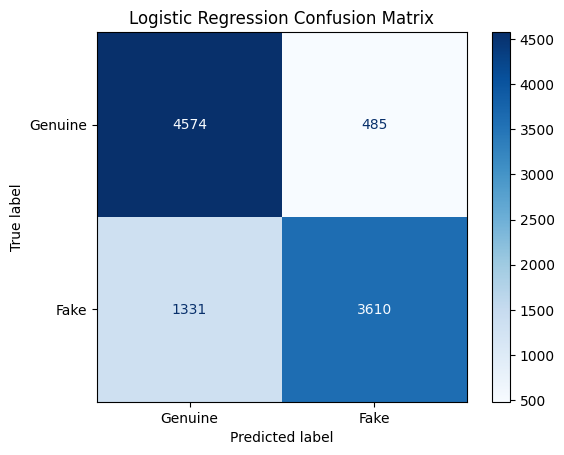

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_lr = lr.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fake"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [35]:
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Metrics:
Accuracy: 0.9446
Precision: 0.9919264409060328
Recall: 0.8951629224853268
F1 Score: 0.941063829787234


Confusion Matrix:
[[5023   36]
 [ 518 4423]]


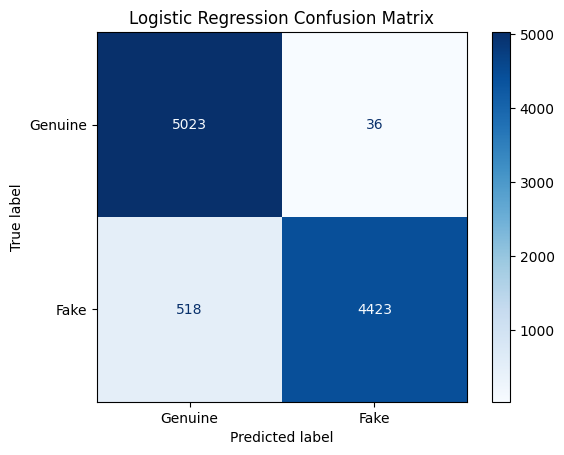

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_rf = rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fake"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [37]:
from textblob import TextBlob
from scipy.sparse import hstack

texts = [
    "Amazing product!!! Best ever!!!",
    "This is a product",
    "Battery lasts 8 hours and build quality is good",
    "Worst product, stopped working in 2 days",
    "I love it so much!!! Highly recommended!!!"
]

for review in texts:

    # TF-IDF vector
    text_vec = tfidf.transform([review])

    # Metadata features
    sentiment = TextBlob(review).sentiment.polarity

    mismatch = int(
        ((5 >= 4) and (sentiment < 0)) or
        ((5 <= 2) and (sentiment > 0))
    )

    has_image = 0          # No image provided
    exclamation_count = review.count("!")

    caps_ratio = (
        sum(c.isupper() for c in review) / (len(review) + 1)
    )

    extra_features = [[
        5,                      # rating
        1,                      # is_verified
        0,                      # helpful_vote
        len(review),            # review_length
        len(review.split()),    # word_count
        sentiment,              # sentiment
        mismatch,               # mismatch
        has_image,              # has_image
        exclamation_count,      # exclamation_count
        caps_ratio              # caps_ratio
    ]]

    final_input = hstack([text_vec, extra_features])

    pred = rf.predict(final_input)

    print(f"{review}\nPrediction: {'Fake' if pred[0] == 1 else 'Genuine'}\n")

Amazing product!!! Best ever!!!
Prediction: Fake

This is a product
Prediction: Fake

Battery lasts 8 hours and build quality is good
Prediction: Genuine

Worst product, stopped working in 2 days
Prediction: Fake

I love it so much!!! Highly recommended!!!
Prediction: Fake



# **Using XGBoost Model Train**

In [38]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/final_labeled_fake_reviews.csv")
# Drop rows with missing text or title
df = df.dropna(subset=['text', 'title'])


In [39]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,label,user_timestamp,user_review_burst
0,5,You will love it!,It’s battery powered! Love love it! Works perf...,[],B07CVHWC68,B07CVHWC68,AHX4JB6F63PSFWZQFFT25RWUHUBQ,3/2/2021 1:53,0,True,0,99999,99999.0
1,5,"Good, clean soap",Good stuff! Yes - it's weird to cover yoursel...,[],B00T6PYPII,B00T6PYPII,AG3VGU4WE6EMBVINQJXNOAXYBU6Q,3/30/2017 16:06,3,True,0,99999,99999.0
2,5,Love It !!!,I've had this for a little over a month now an...,[],B000A23CQM,B000A23CQM,AG3RTC4CY5NWUGG4342GDMGGNKYA,7/24/2008 14:33,0,False,1,99999,99999.0
3,2,Two Stars,Lashes ere too short didn’t fit my eye,[],B00KDIW98K,B00KDIW98K,AEO7IGCEYEDB4J2I7WODOWKR2EMA,11/21/2017 2:06,0,True,0,99999,99999.0
4,1,I can’t used,The magnet doesn’t work is impossible to used....,[],B09LR3G8QL,B09LR3G8QL,AEI4DI2SS5R3KZ4PJ47FR6WZI2KA,12/23/2021 22:53,0,True,0,99999,99999.0


In [40]:
df.shape

(49980, 13)

In [41]:
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'&lt;.*?&gt;', ' ', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [42]:
df['clean_text'] = df['text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)
df['combined_text'] = df['clean_title'] + ' ' + df['clean_text']

In [43]:
for col in ['user_timestamp', 'user_review_burst']:
    df[col] = df[col].replace(99999, np.nan)
    df[col] = df[col].fillna(df[col].median())

print(df.shape, df['label'].value_counts())

(49980, 16) label
0    25278
1    24702
Name: count, dtype: int64


In [44]:
# Metadata features
df['text_len']       = df['clean_text'].str.len()
df['word_count']     = df['clean_text'].str.split().str.len()
df['exclaim_count']  = df['text'].str.count('!')
df['caps_ratio']     = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)
df['verified_int']   = df['verified_purchase'].astype(int)
df['has_image']      = (df['images'] != '[]').astype(int)

META_COLS = [
    'rating', 'helpful_vote', 'verified_int',
    'text_len', 'word_count', 'exclaim_count',
    'caps_ratio', 'has_image'
]

print("Metadata features:", META_COLS)

Metadata features: ['rating', 'helpful_vote', 'verified_int', 'text_len', 'word_count', 'exclaim_count', 'caps_ratio', 'has_image']


In [45]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,...,user_review_burst,clean_text,clean_title,combined_text,text_len,word_count,exclaim_count,caps_ratio,verified_int,has_image
0,5,You will love it!,It’s battery powered! Love love it! Works perf...,[],B07CVHWC68,B07CVHWC68,AHX4JB6F63PSFWZQFFT25RWUHUBQ,3/2/2021 1:53,0,True,...,6444999.5,it s battery powered love love it works perfec...,you will love it,you will love it it s battery powered love lov...,169,31,3,0.034091,1,0
1,5,"Good, clean soap",Good stuff! Yes - it's weird to cover yoursel...,[],B00T6PYPII,B00T6PYPII,AG3VGU4WE6EMBVINQJXNOAXYBU6Q,3/30/2017 16:06,3,True,...,6444999.5,good stuff yes it s weird to cover yourself wi...,good clean soap,good clean soap good stuff yes it s weird to c...,166,33,2,0.022346,1,0
2,5,Love It !!!,I've had this for a little over a month now an...,[],B000A23CQM,B000A23CQM,AG3RTC4CY5NWUGG4342GDMGGNKYA,7/24/2008 14:33,0,False,...,6444999.5,i ve had this for a little over a month now an...,love it,love it i ve had this for a little over a mont...,111,26,3,0.161017,0,0
3,2,Two Stars,Lashes ere too short didn’t fit my eye,[],B00KDIW98K,B00KDIW98K,AEO7IGCEYEDB4J2I7WODOWKR2EMA,11/21/2017 2:06,0,True,...,6444999.5,lashes ere too short didn t fit my eye,two stars,two stars lashes ere too short didn t fit my eye,38,9,0,0.025641,1,0
4,1,I can’t used,The magnet doesn’t work is impossible to used....,[],B09LR3G8QL,B09LR3G8QL,AEI4DI2SS5R3KZ4PJ47FR6WZI2KA,12/23/2021 22:53,0,True,...,6444999.5,the magnet doesn t work is impossible to used ...,i can t used,i can t used the magnet doesn t work is imposs...,75,17,0,0.025974,1,0


In [46]:
df["has_image"].value_counts()

,count
has_image,
0,46107
1,3873


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df[['combined_text'] + META_COLS]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=3
    ), 'combined_text'),
    ('meta', StandardScaler(), META_COLS)
])

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 39984 | Test size: 9996


In [48]:
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import f1_score
# import xgboost as xgb
# import warnings
# import time

# warnings.filterwarnings("ignore", category=UserWarning)

# X_train_proc = preprocessor.fit_transform(X_train)
# X_test_proc  = preprocessor.transform(X_test)

# params = {
#     'objective':        'binary:logistic',
#     'eval_metric':      'logloss',
#     'max_depth':        6,
#     'learning_rate':    0.1,
#     'subsample':        0.8,
#     'colsample_bytree': 0.8,
#     'tree_method':      'hist',
#     'device':           'cuda',
#     'seed':             42
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = []
# booster = None

# print("Starting 5-Fold Cross-Validation...")
# print("-" * 45)

# for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_proc, y_train), 1):
#     t0 = time.time()

#     dtrain_fold = xgb.DMatrix(X_train_proc[train_idx], label=y_train.iloc[train_idx])
#     dval_fold   = xgb.DMatrix(X_train_proc[val_idx],   label=y_train.iloc[val_idx])

#     booster = xgb.train(
#         params,
#         dtrain_fold,
#         num_boost_round=300,
#         evals=[(dval_fold, 'val')],
#         verbose_eval=100
#     )

#     y_pred_val = (booster.predict(dval_fold) >= 0.5).astype(int)
#     score = f1_score(y_train.iloc[val_idx], y_pred_val)
#     cv_scores.append(score)
#     elapsed = time.time() - t0

#     print(f"Fold {fold} → F1: {score:.4f}  ({elapsed:.1f}s)")
#     print("-" * 45)

# print(f"\nMean CV F1 : {sum(cv_scores)/len(cv_scores):.4f}")
# print(f"Std CV F1  : {(sum((s - sum(cv_scores)/len(cv_scores))**2 for s in cv_scores)/len(cv_scores))**0.5:.4f}")

# print("\nFitting final model on full training set...")
# dtrain_full = xgb.DMatrix(X_train_proc, label=y_train)
# booster = xgb.train(
#     params,
#     dtrain_full,
#     num_boost_round=300,
#     verbose_eval=50
# )
# print("Done!")

# dtest = xgb.DMatrix(X_test_proc, label=y_test)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import xgboost as xgb
import warnings
import time

warnings.filterwarnings("ignore", category=UserWarning)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

params = {
    'objective':        'binary:logistic',
    'eval_metric':      'logloss',
    'max_depth':        6,
    'learning_rate':    0.1,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'tree_method':      'hist',
    'device':           'cuda',
    'seed':             42
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores    = []
best_rounds  = []
best_score   = 0
best_booster = None

print("Starting 5-Fold Cross-Validation...")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_proc, y_train), 1):
    t0 = time.time()

    dtrain_fold = xgb.DMatrix(X_train_proc[train_idx], label=y_train.iloc[train_idx])
    dval_fold   = xgb.DMatrix(X_train_proc[val_idx],   label=y_train.iloc[val_idx])

    booster = xgb.train(
        params,
        dtrain_fold,
        num_boost_round=1000,          # high ceiling, early stopping cuts it
        evals=[(dval_fold, 'val')],
        verbose_eval=100,
        early_stopping_rounds=30       # stops if no improvement for 30 rounds
    )

    y_pred_val = (booster.predict(dval_fold) >= 0.5).astype(int)
    score      = f1_score(y_train.iloc[val_idx], y_pred_val)
    cv_scores.append(score)
    best_rounds.append(booster.best_iteration)
    elapsed = time.time() - t0

    if score > best_score:
        best_score   = score
        best_booster = booster

    print(f"Fold {fold} → F1: {score:.4f}  rounds: {booster.best_iteration}  ({elapsed:.1f}s)")
    print("-" * 45)

print(f"\nMean CV F1   : {sum(cv_scores)/len(cv_scores):.4f}")
print(f"Std CV F1    : {(sum((s-sum(cv_scores)/len(cv_scores))**2 for s in cv_scores)/len(cv_scores))**0.5:.4f}")
print(f"Best CV F1   : {best_score:.4f}")
print(f"Avg rounds   : {int(sum(best_rounds)/len(best_rounds))}")
print(f"Best rounds  : {max(best_rounds)}")

# Final fit using average best rounds from CV — not hardcoded 300
optimal_rounds = int(sum(best_rounds) / len(best_rounds))
print(f"\nFitting final model with {optimal_rounds} rounds...")
dtrain_full = xgb.DMatrix(X_train_proc, label=y_train)
booster = xgb.train(
    params,
    dtrain_full,
    num_boost_round=optimal_rounds,
    verbose_eval=50
)
print("Done!")

dtest = xgb.DMatrix(X_test_proc, label=y_test)

Starting 5-Fold Cross-Validation...
---------------------------------------------
[0]	val-logloss:0.63263
[100]	val-logloss:0.07891
[200]	val-logloss:0.07425
[300]	val-logloss:0.07338
[377]	val-logloss:0.07332
Fold 1 → F1: 0.9775  rounds: 347  (11.4s)
---------------------------------------------
[0]	val-logloss:0.63125
[100]	val-logloss:0.06990
[200]	val-logloss:0.06407
[300]	val-logloss:0.06239
[400]	val-logloss:0.06138
[480]	val-logloss:0.06090
Fold 2 → F1: 0.9808  rounds: 450  (12.3s)
---------------------------------------------
[0]	val-logloss:0.63178
[100]	val-logloss:0.07985
[200]	val-logloss:0.07466
[263]	val-logloss:0.07421
Fold 3 → F1: 0.9769  rounds: 233  (7.2s)
---------------------------------------------
[0]	val-logloss:0.63275
[100]	val-logloss:0.07742
[200]	val-logloss:0.07243
[294]	val-logloss:0.07239
Fold 4 → F1: 0.9793  rounds: 264  (8.0s)
---------------------------------------------
[0]	val-logloss:0.63159
[100]	val-logloss:0.07979
[200]	val-logloss:0.07591
[259]	

In [49]:
import pickle
import os

# make sure folder exists
os.makedirs('/content/drive/MyDrive/models', exist_ok=True)

# save booster
booster.save_model('/content/drive/MyDrive/models/fake_review_booster_v2.json')

# save preprocessor to Drive
with open('/content/drive/MyDrive/models/preprocessor_v2.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("booster      → /content/drive/MyDrive/models/fake_review_booster_v2.json")
print("preprocessor → /content/drive/MyDrive/models/preprocessor_v2.pkl")

booster      → /content/drive/MyDrive/models/fake_review_booster_v2.json
preprocessor → /content/drive/MyDrive/models/preprocessor_v2.pkl


Models loaded successfully!
=== Test Set Results ===
Accuracy : 0.9794
F1 Score : 0.9789
Recall : 0.9688
Precision : 0.9893

              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      5056
        Fake       0.99      0.97      0.98      4940

    accuracy                           0.98      9996
   macro avg       0.98      0.98      0.98      9996
weighted avg       0.98      0.98      0.98      9996



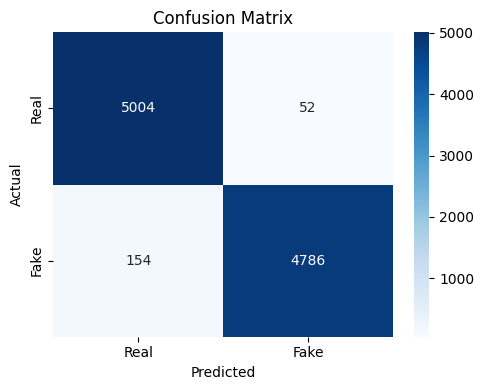


Top 15 features by gain:
---------------------------------------------
  verified_int                    591.79
  word_count                      327.57
  exclaim_count                   153.33
  text_len                        137.61
  see                             133.16
  seems                           122.17
  seem                            82.58
  seen                            51.89
  photo                           45.88
  seemed                          42.65
  seeing                          27.62
  look at                         25.72
  rating                          24.10
  image                           23.10
  photos                          21.15


In [52]:
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import xgboost as xgb

booster = xgb.Booster()
booster.load_model('/content/drive/MyDrive/models/fake_review_booster_v2.json')

with open('/content/drive/MyDrive/models/preprocessor_v2.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

print("Models loaded successfully!")
# Predictions from booster
y_pred = (booster.predict(dtest) >= 0.5).astype(int)

print("=== Test Set Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"Recall : {recall_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Top 15 feature importances
tfidf_feat   = preprocessor.named_transformers_['tfidf'].get_feature_names_out()
all_features = np.concatenate([tfidf_feat, META_COLS])

scores = booster.get_score(importance_type='gain')

# Map f0, f1... back to feature names
importance_vals = np.array([scores.get(f'f{i}', 0) for i in range(len(all_features))])
top_idx = importance_vals.argsort()[-15:][::-1]

print("\nTop 15 features by gain:")
print("-" * 45)
for i in top_idx:
    print(f"  {all_features[i]:30s}  {importance_vals[i]:.2f}")

In [53]:
import pandas as pd
import re

#Raw inputs from e-commerce platform
review_text      = 'amazing product best purchase but not highly recommend'
review_title     = 'Love it'
rating           = 5
helpful_vote     = 50
verified_purchase= True        # from order database
user_timestamp   = 3            # days since account creation
user_review_burst= 1           # no. of reviews user posted this week
has_image        = True        # did user attach a photo

# ----- Feature engineering (runs on server) -----
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'<.*?>', ' ', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

clean  = clean_text(review_text)
title  = clean_text(review_title)
combined = title + ' ' + clean

custom = {
    # text (raw input)
    'combined_text':     combined,

    # from order/user database
    'rating':            rating,
    'helpful_vote':      helpful_vote,
    'verified_int':      int(verified_purchase),
    'user_timestamp':    user_timestamp,
    'user_review_burst': user_review_burst,
    'has_image':         int(has_image),

    # auto-derived from text on server side
    'text_len':          len(clean),
    'word_count':        len(clean.split()),
    'exclaim_count':     review_text.count('!'),
    'caps_ratio':        sum(1 for c in review_text if c.isupper()) / (len(review_text) + 1),
}

custom_df   = pd.DataFrame([custom])
custom_proc = preprocessor.transform(custom_df)
custom_dmat = xgb.DMatrix(custom_proc)

prob  = booster.predict(custom_dmat)[0]
label = int(prob >= 0.5)

print("=== Review Submitted ===")
print(f"Text      : {review_text}")
print(f"Rating    : {rating}")
print(f"Verified  : {verified_purchase}")
print()
print(f"Fake probability : {prob:.4f}")
print(f"Prediction       : {'FAKE — flagged for moderation' if label == 1 else 'REAL — approved'}")

=== Review Submitted ===
Text      : amazing product best purchase but not highly recommend
Rating    : 5
Verified  : True

Fake probability : 0.5978
Prediction       : FAKE — flagged for moderation
